# Tutorial 4: Unstructured Pruning on Bert

Pruning is a technique used to reduce the size and complexity of neural networks by removing unnecessary parameters (weights and connections) or structural components (neurons, filters, or layers). The goal is to create a smaller, more efficient model that maintains most of the original model's performance. The following benefits can be seen from pruning neural networks:

- **Reduce model size**: Deep neural networks often have millions of parameters, leading to large storage requirements.

- **Decrease inference time**: Fewer parameters mean fewer computations, resulting in faster predictions.

- **Improve generalization**: Removing unnecessary connections can help prevent overfitting.

- **Energy efficiency**: Smaller models require less energy to run, which is crucial for edge devices and mobile applications.

Structured pruning removes entire structures (e.g., channels, filters, or layers) from the network, while unstructured pruning removes individual weights or connections from the network, regardless of their location. In this tutorial, we'll build on top of Tutorial 3 by taking the quantized Bert model and running Mase's unstructured pruning pass. After pruning, we'll run further fine tuning iterations to retain sequence classification accuracy in the pruned model.

In [1]:
checkpoint = "prajjwal1/bert-tiny"
tokenizer_checkpoint = "bert-base-uncased"
dataset_name = "imdb"

## Importing the model

If you are starting from scratch, you can create a MaseGraph for Bert by running the following cell.

In [2]:
from transformers import AutoModelForSequenceClassification

from chop import MaseGraph
import chop.passes as passes

model = AutoModelForSequenceClassification.from_pretrained(checkpoint)
model.config.problem_type = "single_label_classification"

mg = MaseGraph(
    model,
    hf_input_names=[
        "input_ids",
        "attention_mask",
        "labels",
    ],
)

mg, _ = passes.init_metadata_analysis_pass(mg)
mg, _ = passes.add_common_metadata_analysis_pass(mg)

/vol/bitbucket/rr422/adls_labs_group_13/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/vol/bitbucket/rr422/adls_labs_group_13/.venv/lib/python3.11/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at prajjwal1/bert-tiny and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
`past_key_values` were not specified as input names, but model.config.use

tensor([[ 101, 9932, 2089, 2202, 2058, 1996, 2088, 2028, 2154,  102],
        [ 101, 2023, 2003, 2339, 2017, 2323, 4553, 4748, 4877,  102]])
tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])
tensor([[ 101, 9932, 2089, 2202, 2058, 1996, 2088, 2028, 2154,  102],
        [ 101, 2023, 2003, 2339, 2017, 2323, 4553, 4748, 4877,  102]])
tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])
tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])
tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])
tensor([[[[1, 1, 1, 1, 1, 1, 1, 1, 1, 1]]],


        [[[1, 1, 1, 1, 1, 1, 1, 1, 1, 1]]]])
tensor([[[[1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
          [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
          [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
          [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
          [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
          [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
          [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
          [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
       

If you have previously ran the tutorial on Quantization-Aware Training (QAT), run the following cell to import the fine tuned checkpoint.

In [3]:
from pathlib import Path
from chop import MaseGraph

mg = MaseGraph.from_checkpoint(f"{Path.home()}/tutorial_3_qat")

## Unstructured Pruning

Before running pruning, let's evaluate the model accuracy on the IMDb dataset. If you're coming from Tutorial, this would be the same as the accuracy after Quantization Aware Training (QAT). If you've just initialized the model, this will likely be a random guess (i.e. around 50%), in which case pruning wouldn't have a significant effect on the accuracy.

In [4]:
from chop.tools import get_tokenized_dataset, get_trainer

dataset, tokenizer = get_tokenized_dataset(
    dataset=dataset_name,
    checkpoint=tokenizer_checkpoint,
    return_tokenizer=True,
)

trainer = get_trainer(
    model=mg.model,
    tokenized_dataset=dataset,
    tokenizer=tokenizer,
    evaluate_metric="accuracy",
)

# Evaluate accuracy
eval_results = trainer.evaluate()
print(f"Evaluation accuracy: {eval_results['eval_accuracy']}")

INFO     Tokenizing dataset imdb with AutoTokenizer for bert-base-uncased.
/vol/bitbucket/rr422/adls_labs_group_13/src/chop/tools/huggingface.py:157: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Evaluation accuracy: 0.8404


To run the pruning pass, we pass the following pruning configuration dictionary, which defines the following parameters.

- **Sparsity**: a value between 0 and 1, expressing the proportion of elements in the model that should be pruned (i.e. set to 0).

- **Method**: several pruning methods are supported, including ``Random`` and ``L1-Norm``.

- **Scope**: defines whether to consider each weight/activation tensor individually (``local``) or all tensors in the model (``global``) when obtaining statistics for pruning (e.g. absolute value threshold for pruning)

We'll start by running random pruning with local scope, at a fixed sparsity. This may be suboptimal, but in future tutorials we'll see how to find optimal pruning and quantization configurations for a given model on a specified dataset.

In [5]:
import chop.passes as passes

pruning_config = {
    "weight": {
        "sparsity": 0.5,
        "method": "l1-norm",
        "scope": "local",
    },
    "activation": {
        "sparsity": 0.5,
        "method": "l1-norm",
        "scope": "local",
    },
}

mg, _ = passes.prune_transform_pass(mg, pass_args=pruning_config)

INFO     Pruning module: bert_encoder_layer_0_attention_self_query
INFO     Pruning module: bert_encoder_layer_0_attention_self_key
INFO     Pruning module: bert_encoder_layer_0_attention_self_value
INFO     Pruning module: bert_encoder_layer_0_attention_output_dense
INFO     Pruning module: bert_encoder_layer_0_intermediate_dense
INFO     Pruning module: bert_encoder_layer_0_output_dense
INFO     Pruning module: bert_encoder_layer_1_attention_self_query
INFO     Pruning module: bert_encoder_layer_1_attention_self_key
INFO     Pruning module: bert_encoder_layer_1_attention_self_value
INFO     Pruning module: bert_encoder_layer_1_attention_output_dense
INFO     Pruning module: bert_encoder_layer_1_intermediate_dense
INFO     Pruning module: bert_encoder_layer_1_output_dense
INFO     Pruning module: bert_pooler_dense
INFO     Pruning module: classifier


Let's evaluate the effect of pruning on accuracy. It's likely to observe drops of around 10% or more.

In [6]:
trainer = get_trainer(
    model=mg.model,
    tokenized_dataset=dataset,
    tokenizer=tokenizer,
    evaluate_metric="accuracy",
    num_train_epochs=5,
)

# Evaluate accuracy
eval_results = trainer.evaluate()
print(f"Evaluation accuracy: {eval_results['eval_accuracy']}")

/vol/bitbucket/rr422/adls_labs_group_13/src/chop/tools/huggingface.py:157: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Evaluation accuracy: 0.77936


To overcome the drop in accuracy, we'll run a few finetuning epochs. This allows the model to adapt to the new pruning mask.

In [7]:
trainer.train()

Step,Training Loss
500,0.446800
1000,0.422300
1500,0.425200
2000,0.400100
2500,0.406000
3000,0.413200
3500,0.419200
4000,0.402500
4500,0.394400
5000,0.396800


TrainOutput(global_step=15625, training_loss=0.3964231708984375, metrics={'train_runtime': 187.8426, 'train_samples_per_second': 665.451, 'train_steps_per_second': 83.181, 'total_flos': 0.0, 'train_loss': 0.3964231708984375, 'epoch': 5.0})

Let's evaluate the model accuracy after finetuning. We should see that the accuracy is reverted back to the original level.

In [8]:
eval_results = trainer.evaluate()
print(f"Evaluation accuracy: {eval_results['eval_accuracy']}")

Evaluation accuracy: 0.8342


### Lab 1.2.a


--- Initializing 16-bit Quantization Base ---


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at prajjwal1/bert-tiny and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
`past_key_values` were not specified as input names, but model.config.use_cache = True. Setting model.config.use_cache = False.
INFO     Getting dummy input for prajjwal1/bert-tiny.
INFO     Exporting MaseGraph to /homes/rr422/temp_16bit_qat.pt, /homes/rr422/temp_16bit_qat.mz
INFO     Exporting GraphModule to /homes/rr422/temp_16bit_qat.pt
INFO     Saving full model format
INFO     Exporting MaseMetadata to /homes/rr422/temp_16bit_qat.mz


tensor([[ 101, 9932, 2089, 2202, 2058, 1996, 2088, 2028, 2154,  102],
        [ 101, 2023, 2003, 2339, 2017, 2323, 4553, 4748, 4877,  102]])
tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])
tensor([[ 101, 9932, 2089, 2202, 2058, 1996, 2088, 2028, 2154,  102],
        [ 101, 2023, 2003, 2339, 2017, 2323, 4553, 4748, 4877,  102]])
tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])
tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])
tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
        [1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])
tensor([[[[1, 1, 1, 1, 1, 1, 1, 1, 1, 1]]],


        [[[1, 1, 1, 1, 1, 1, 1, 1, 1, 1]]]])
tensor([[[[1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
          [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
          [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
          [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
          [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
          [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
          [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
          [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
       

WARNING  Failed to pickle call_function node: finfo
WARNING  cannot pickle 'torch.finfo' object
WARNING  Failed to pickle call_function node: getattr_2
WARNING  cannot pickle 'torch.finfo' object
INFO     Tokenizing dataset imdb with AutoTokenizer for bert-base-uncased.


Intermediate 16-bit model saved to /homes/rr422/temp_16bit_qat

--- Starting Pruning Sweep on 16-bit Model ---

Processing Sparsity: 0.1


...

WARNING  Node finfo not found in loaded metadata.
WARNING  Node getattr_2 not found in loaded metadata.
INFO     Pruning module: bert_encoder_layer_0_attention_self_query
INFO     Pruning module: bert_encoder_layer_0_attention_self_key
INFO     Pruning module: bert_encoder_layer_0_attention_self_value
INFO     Pruning module: bert_encoder_layer_0_attention_output_dense
INFO     Pruning module: bert_encoder_layer_0_intermediate_dense
INFO     Pruning module: bert_encoder_layer_0_output_dense
INFO     Pruning module: bert_encoder_layer_1_attention_self_query
INFO     Pruning module: bert_encoder_layer_1_attention_self_key
INFO     Pruning module: bert_encoder_layer_1_attention_self_value
INFO     Pruning module: bert_encoder_layer_1_attention_output_dense
INFO     Pruning module: bert_encoder_layer_1_intermediate_dense
INFO     Pruning module: bert_encoder_layer_1_output_dense
INFO     Pruning module: bert_pooler_dense
INFO     Pruning module: classifier


--> Achieved Accuracy: 0.6794

Processing Sparsity: 0.9


/vol/bitbucket/rr422/adls_labs_group_13/src/chop/tools/huggingface.py:157: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss
500,0.694600
1000,0.693400
1500,0.692500
2000,0.692000
2500,0.691300
3000,0.691900


--> Achieved Accuracy: 0.5017


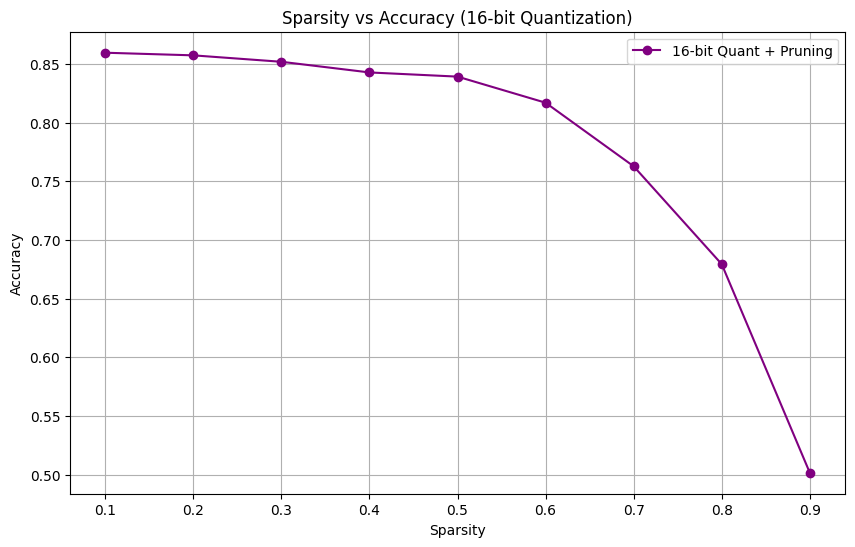

In [9]:
import matplotlib.pyplot as plt
import chop.passes as passes
from chop import MaseGraph
from pathlib import Path
from chop.tools import get_trainer
import torch
import torch.fx.graph_module
from transformers import AutoModelForSequenceClassification, PretrainedConfig
from transformers.utils.fx import HFTracer


if not hasattr(torch.fx.graph_module._CodeOnlyModule, "device"):
    setattr(torch.fx.graph_module._CodeOnlyModule, "device", property(lambda self: torch.device("cpu")))

if not hasattr(HFTracer, "_original_generate_dummy_input"):
    HFTracer._original_generate_dummy_input = HFTracer._generate_dummy_input
    def _patched_generate_dummy_input(self, model, input_name, shape, input_names=None):
        if type(model).__name__ == "_CodeOnlyModule" and input_name == "labels":
            device = getattr(model, "device", torch.device("cpu"))
            label_shape = (shape[0],) if len(shape) > 0 else (1,)
            return {"labels": torch.zeros(label_shape, dtype=torch.long, device=device)}
        return HFTracer._original_generate_dummy_input(self, model, input_name, shape, input_names)
    HFTracer._generate_dummy_input = _patched_generate_dummy_input


# We initialize a MaseGraph from the float model to apply 16-bit quantization.
print("\n--- Initializing 16-bit Quantization Base ---")
model = AutoModelForSequenceClassification.from_pretrained("prajjwal1/bert-tiny")
model.config.problem_type = "single_label_classification"

mg = MaseGraph(model, hf_input_names=["input_ids", "attention_mask", "labels"])
mg, _ = passes.init_metadata_analysis_pass(mg)
mg, _ = passes.add_common_metadata_analysis_pass(mg)

quant_config_16 = {
    "by": "type",
    "default": {"config": {"name": None}},
    "linear": {
        "config": {
            "name": "integer",
            "data_in_width": 16, "data_in_frac_width": 8,
            "weight_width": 16, "weight_frac_width": 8,
            "bias_width": 16, "bias_frac_width": 8,
        }
    },
}

mg, _ = passes.quantize_transform_pass(mg, pass_args=quant_config_16)

# Save this "Quantized 16-bit" state so we can reload it fresh for each sparsity level
temp_checkpoint_path = Path.home() / "temp_16bit_qat"
mg.export(str(temp_checkpoint_path), save_format="checkpoint")
print(f"Intermediate 16-bit model saved to {temp_checkpoint_path}")


sparsities = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
sweep_results = []
dataset, tokenizer = get_tokenized_dataset(dataset="imdb", checkpoint="bert-base-uncased", return_tokenizer=True)

print("\n--- Starting Pruning Sweep on 16-bit Model ---")

for s in sparsities:
    print(f"\nProcessing Sparsity: {s}")
    

    mg_run = MaseGraph.from_checkpoint(str(temp_checkpoint_path))
    
    # Using L1-Norm as a standard default for this experiment
    pruning_conf = {
        "weight": {"sparsity": s, "method": "l1-norm", "scope": "local"},
        "activation": {"sparsity": s, "method": "l1-norm", "scope": "local"},
    }
    
    mg_run, _ = passes.prune_transform_pass(mg_run, pass_args=pruning_conf)

    trainer = get_trainer(
        model=mg_run.model,
        tokenized_dataset=dataset,
        tokenizer=tokenizer,
        evaluate_metric="accuracy",
        num_train_epochs=1
    )
    trainer.train()
    

    metrics = trainer.evaluate()
    acc = metrics['eval_accuracy']
    sweep_results.append(acc)
    print(f"--> Achieved Accuracy: {acc:.4f}")

# 5. Plot Results
plt.figure(figsize=(10, 6))
plt.plot(sparsities, sweep_results, marker='o', linestyle='-', color='purple', label="16-bit Quant + Pruning")
plt.title("Sparsity vs Accuracy (16-bit Quantization)")
plt.xlabel("Sparsity")
plt.ylabel("Accuracy")
plt.grid(True)
plt.legend()
plt.show()

### Lab 1.2.a Plot a figure where the x-axis is the sparsity and the y-axis is the highest achieved accuracy on the IMDb dataset, following the procedure in Tutorial 4.

In [10]:
import matplotlib.pyplot as plt
import chop.passes as passes
from chop import MaseGraph
from pathlib import Path
from chop.tools import get_trainer
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Running on: {device.upper()}")
if device == "cuda":
    print(f"Device Name: {torch.cuda.get_device_name(0)}")

# range of sparsities
sparsities = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
methods = ["l1-norm", "random"]
results = {method: [] for method in methods}

print("Starting Pruning Sweep...")

for method in methods:
    print(f"\n=== Testing Method: {method} ===")
    for s in sparsities:
        print(f"\n--- Testing Sparsity: {s} ---")
        
        # Reload the model fresh from the previous tutorial checkpoint
        mg_experiment = MaseGraph.from_checkpoint(f"{Path.home()}/tutorial_3_qat")
        
        current_config = {
            "weight": {
                "sparsity": s,
                "method": method,
                "scope": "local",
            },
            "activation": {
                "sparsity": s,
                "method": method,
                "scope": "local",
            },
        }

        # Pruning Pass
        mg_experiment, _ = passes.prune_transform_pass(
            mg_experiment, 
            pass_args=current_config
        )

        
        trainer = get_trainer(
            model=mg_experiment.model,
            tokenized_dataset=dataset,
            tokenizer=tokenizer,
            evaluate_metric="accuracy",
            num_train_epochs=5 
        )
        
        trainer.train()
        
        # Record Best Accuracy
        eval_results = trainer.evaluate()
        acc = eval_results['eval_accuracy']
        results[method].append(acc)
        print(f"Sparsity: {s} | Method: {method} | Accuracy: {acc:.4f}")



INFO     Pruning module: bert_encoder_layer_0_attention_self_query
INFO     Pruning module: bert_encoder_layer_0_attention_self_key
INFO     Pruning module: bert_encoder_layer_0_attention_self_value
INFO     Pruning module: bert_encoder_layer_0_attention_output_dense
INFO     Pruning module: bert_encoder_layer_0_intermediate_dense
INFO     Pruning module: bert_encoder_layer_0_output_dense
INFO     Pruning module: bert_encoder_layer_1_attention_self_query
INFO     Pruning module: bert_encoder_layer_1_attention_self_key
INFO     Pruning module: bert_encoder_layer_1_attention_self_value
INFO     Pruning module: bert_encoder_layer_1_attention_output_dense
INFO     Pruning module: bert_encoder_layer_1_intermediate_dense
INFO     Pruning module: bert_encoder_layer_1_output_dense
INFO     Pruning module: bert_pooler_dense
INFO     Pruning module: classifier


Running on: CUDA
Device Name: NVIDIA GeForce RTX 4080
Starting Pruning Sweep...

=== Testing Method: l1-norm ===

--- Testing Sparsity: 0.1 ---


/vol/bitbucket/rr422/adls_labs_group_13/src/chop/tools/huggingface.py:157: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss
500,0.368600
1000,0.377400
1500,0.380500
2000,0.381700
2500,0.379300
3000,0.388800
3500,0.404200
4000,0.369500
4500,0.373500
5000,0.369700


INFO     Pruning module: bert_encoder_layer_0_attention_self_query
INFO     Pruning module: bert_encoder_layer_0_attention_self_key
INFO     Pruning module: bert_encoder_layer_0_attention_self_value
INFO     Pruning module: bert_encoder_layer_0_attention_output_dense
INFO     Pruning module: bert_encoder_layer_0_intermediate_dense
INFO     Pruning module: bert_encoder_layer_0_output_dense
INFO     Pruning module: bert_encoder_layer_1_attention_self_query
INFO     Pruning module: bert_encoder_layer_1_attention_self_key
INFO     Pruning module: bert_encoder_layer_1_attention_self_value
INFO     Pruning module: bert_encoder_layer_1_attention_output_dense
INFO     Pruning module: bert_encoder_layer_1_intermediate_dense
INFO     Pruning module: bert_encoder_layer_1_output_dense
INFO     Pruning module: bert_pooler_dense
INFO     Pruning module: classifier


...

INFO     Pruning module: bert_encoder_layer_0_attention_self_query
INFO     Pruning module: bert_encoder_layer_0_attention_self_key
INFO     Pruning module: bert_encoder_layer_0_attention_self_value
INFO     Pruning module: bert_encoder_layer_0_attention_output_dense
INFO     Pruning module: bert_encoder_layer_0_intermediate_dense
INFO     Pruning module: bert_encoder_layer_0_output_dense
INFO     Pruning module: bert_encoder_layer_1_attention_self_query
INFO     Pruning module: bert_encoder_layer_1_attention_self_key
INFO     Pruning module: bert_encoder_layer_1_attention_self_value
INFO     Pruning module: bert_encoder_layer_1_attention_output_dense
INFO     Pruning module: bert_encoder_layer_1_intermediate_dense
INFO     Pruning module: bert_encoder_layer_1_output_dense
INFO     Pruning module: bert_pooler_dense
INFO     Pruning module: classifier


Sparsity: 0.8 | Method: random | Accuracy: 0.5017

--- Testing Sparsity: 0.9 ---


/vol/bitbucket/rr422/adls_labs_group_13/src/chop/tools/huggingface.py:157: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Step,Training Loss
500,0.693100
1000,0.693200
1500,0.693100
2000,0.693100
2500,0.693100
3000,0.693100
3500,0.693200
4000,0.693200
4500,0.693200
5000,0.693100


Sparsity: 0.9 | Method: random | Accuracy: 0.4989


### Lab 1.2.b Plot separate curves for Random and L1-Norm methods to evaluate the effect of different pruning strategies.

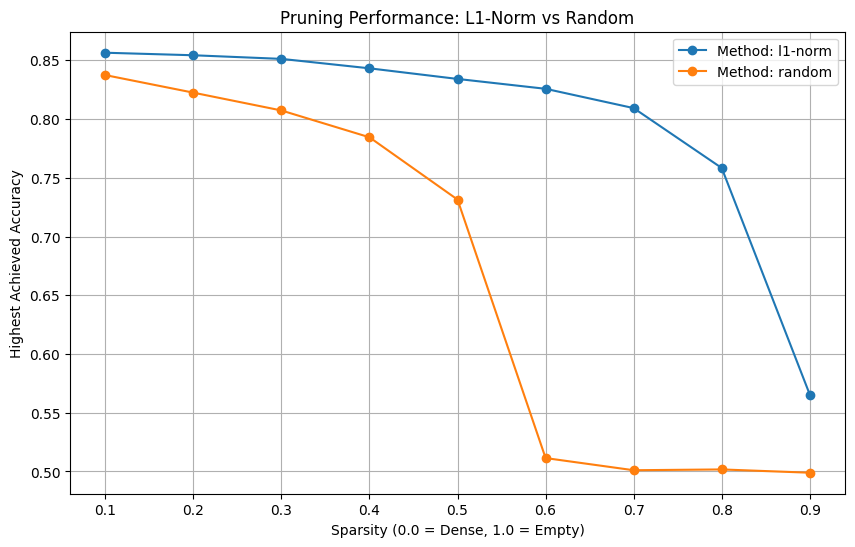

In [11]:
plt.figure(figsize=(10, 6))
for method, accuracies in results.items():
    plt.plot(sparsities, accuracies, marker='o', linestyle='-', label=f'Method: {method}')

plt.title('Pruning Performance: L1-Norm vs Random')
plt.xlabel('Sparsity (0.0 = Dense, 1.0 = Empty)')
plt.ylabel('Highest Achieved Accuracy')
plt.xticks(sparsities)
plt.legend()
plt.grid(True)
plt.show()